# BTC Spot–Perpetual Basis: Real-Data State-Space Research and Backtest

This notebook uses **real Binance `BTCUSDT` spot and USD-M perpetual `aggTrades` data**.

It does four things:

1. Downloads and aligns both real trade streams.
2. Fits the state-space model on an earlier training period only.
3. Produces one-sided, out-of-sample transient signals.
4. Runs a deliberately labelled **last-trade proxy backtest** to measure the gross signal and the effect of fees.

> Important: `aggTrades` does not contain historical bid/ask quotes or queue position.  
> Therefore the backtest below is a research proxy, not proof of executable P&L. It does **not** replace an order-book replay.

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [2]:
from __future__ import annotations

import io
import math
import zipfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from state_space import fit_state_space, filter_state_space, OnlineBasisFilter

plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

## 1. Configuration

In [3]:
# Real Binance data
SYMBOL = "BTCUSDT"
DATE = "2026-07-20"       # settled UTC date
BAR_SECONDS = 1
CACHE_DIR = Path("./data")

# Alignment / data-quality controls
MAX_STALE_SECONDS = 2.0   # discard a bar if either market's last trade is older than this
TRAIN_OBS = 60_000        # first observations used only for parameter fitting

# Signal rules
ENTRY_Z = 2.0
EXIT_Z = 0.25
STOP_Z = 4.0
MAX_HOLD_SECONDS = 60
COOLDOWN_SECONDS = 5

# Economics: each completed round trip has four fills
FEE_BP_PER_FILL = 2.0
SLIPPAGE_BP_PER_FILL = 0.10

# False = only long spot / short perp trades are allowed.
# The opposite direction requires shorting spot BTC and therefore borrow inventory.
ALLOW_SHORT_SPOT = False

# The diagnostic backtest is still run when the economic gate says "no trade";
# this lets us see gross edge versus costs instead of hiding the result.
RUN_DIAGNOSTIC_BACKTEST = True

PERP_URL = "https://data.binance.vision/data/futures/um/daily/aggTrades"
SPOT_URL = "https://data.binance.vision/data/spot/daily/aggTrades"

## 2. Download and construct real one-second bars

In [4]:
PERP_COLUMNS = [
    "agg_trade_id", "price", "quantity", "first_trade_id",
    "last_trade_id", "transact_time", "is_buyer_maker",
]
SPOT_COLUMNS = PERP_COLUMNS + ["is_best_match"]


def _timestamp_unit(values: pd.Series) -> str:
    finite = pd.to_numeric(values, errors="coerce").dropna()
    if finite.empty:
        raise ValueError("No valid timestamps")
    # Binance spot archive uses microseconds from 2025 onward; futures commonly remains ms.
    return "us" if float(finite.median()) > 1e14 else "ms"


def download_agg_trades(symbol: str, date: str, venue: str) -> pd.DataFrame:
    if venue not in {"spot", "perp"}:
        raise ValueError("venue must be 'spot' or 'perp'")

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / f"{symbol}_{date}_{venue}_aggtrades.pkl"
    if cache_path.exists():
        print(f"[cache] {cache_path}")
        return pd.read_pickle(cache_path)

    base = PERP_URL if venue == "perp" else SPOT_URL
    url = f"{base}/{symbol}/{symbol}-aggTrades-{date}.zip"
    print(f"[download] {url}")

    with urlopen(url, timeout=120) as response:
        payload = response.read()

    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        member = archive.namelist()[0]
        with archive.open(member) as handle:
            preview = handle.read(300).decode("utf-8", errors="ignore")
            handle.seek(0)
            has_header = "agg_trade_id" in preview or "transact_time" in preview
            names = PERP_COLUMNS if venue == "perp" else SPOT_COLUMNS
            frame = pd.read_csv(
                handle,
                header=0 if has_header else None,
                names=None if has_header else names,
                low_memory=False,
            )

    # Normalise possible archive/header variants.
    if "transact_time" not in frame.columns:
        frame.columns = names[: len(frame.columns)]

    for col in ("price", "quantity", "transact_time"):
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

    frame = frame.dropna(subset=["price", "quantity", "transact_time"]).copy()
    unit = _timestamp_unit(frame["transact_time"])
    frame["timestamp"] = pd.to_datetime(frame["transact_time"], unit=unit, utc=True)
    frame = frame.sort_values("timestamp").reset_index(drop=True)
    frame.to_pickle(cache_path)
    print(f"[cache] wrote {len(frame):,} trades -> {cache_path}")
    return frame


def to_second_bars(trades: pd.DataFrame, date: str, bar_seconds: int) -> pd.DataFrame:
    if bar_seconds < 1:
        raise ValueError("BAR_SECONDS must be at least one second")

    rule = f"{bar_seconds}s"
    indexed = trades.set_index("timestamp").sort_index()

    bars = indexed.resample(rule).agg(
        last=("price", "last"),
        volume=("quantity", "sum"),
        trades=("price", "size"),
    )

    day_start = pd.Timestamp(date, tz="UTC")
    day_end = day_start + pd.Timedelta(days=1)
    full_index = pd.date_range(
        day_start,
        day_end - pd.Timedelta(seconds=bar_seconds),
        freq=rule,
    )
    bars = bars.reindex(full_index)
    bars.index.name = "timestamp"

    had_trade = bars["last"].notna()
    last_event_time = pd.Series(
        bars.index.where(had_trade),
        index=bars.index,
    ).ffill()

    bars["age_s"] = (
        bars.index.to_series(index=bars.index) - last_event_time
    ).dt.total_seconds()
    bars["last"] = bars["last"].ffill()
    bars["volume"] = bars["volume"].fillna(0.0)
    bars["trades"] = bars["trades"].fillna(0).astype(int)
    bars["had_trade"] = had_trade
    return bars


perp_trades = download_agg_trades(SYMBOL, DATE, "perp")
spot_trades = download_agg_trades(SYMBOL, DATE, "spot")

perp = to_second_bars(perp_trades, DATE, BAR_SECONDS).add_prefix("perp_")
spot = to_second_bars(spot_trades, DATE, BAR_SECONDS).add_prefix("spot_")

raw = perp.join(spot, how="inner")
raw["valid"] = (
    raw["perp_last"].notna()
    & raw["spot_last"].notna()
    & (raw["perp_age_s"] <= MAX_STALE_SECONDS)
    & (raw["spot_age_s"] <= MAX_STALE_SECONDS)
)

aligned = raw.loc[raw["valid"]].copy()
aligned["basis_log"] = np.log(aligned["perp_last"]) - np.log(aligned["spot_last"])
aligned["basis_bp"] = aligned["basis_log"] * 1e4

quality = pd.DataFrame({
    "value": {
        "perpetual aggTrades": len(perp_trades),
        "spot aggTrades": len(spot_trades),
        "all one-second timestamps": len(raw),
        "valid aligned timestamps": len(aligned),
        "valid share": aligned.shape[0] / max(raw.shape[0], 1),
        "basis mean (bp)": aligned["basis_bp"].mean(),
        "basis std (bp)": aligned["basis_bp"].std(),
        "basis min (bp)": aligned["basis_bp"].min(),
        "basis max (bp)": aligned["basis_bp"].max(),
        "max perp age retained (s)": aligned["perp_age_s"].max(),
        "max spot age retained (s)": aligned["spot_age_s"].max(),
    }
})
display(quality)

[cache] data/BTCUSDT_2026-07-20_perp_aggtrades.pkl
[cache] data/BTCUSDT_2026-07-20_spot_aggtrades.pkl


,value
perpetual aggTrades,1.471068e+06
spot aggTrades,9.414820e+05
all one-second timestamps,8.640000e+04
valid aligned timestamps,8.579500e+04
valid share,9.929977e-01
basis mean (bp),-4.235929e+00
basis std (bp),6.875072e-01
basis min (bp),-8.519863e+00
basis max (bp),6.220399e+00
max perp age retained (s),2.000000e+00


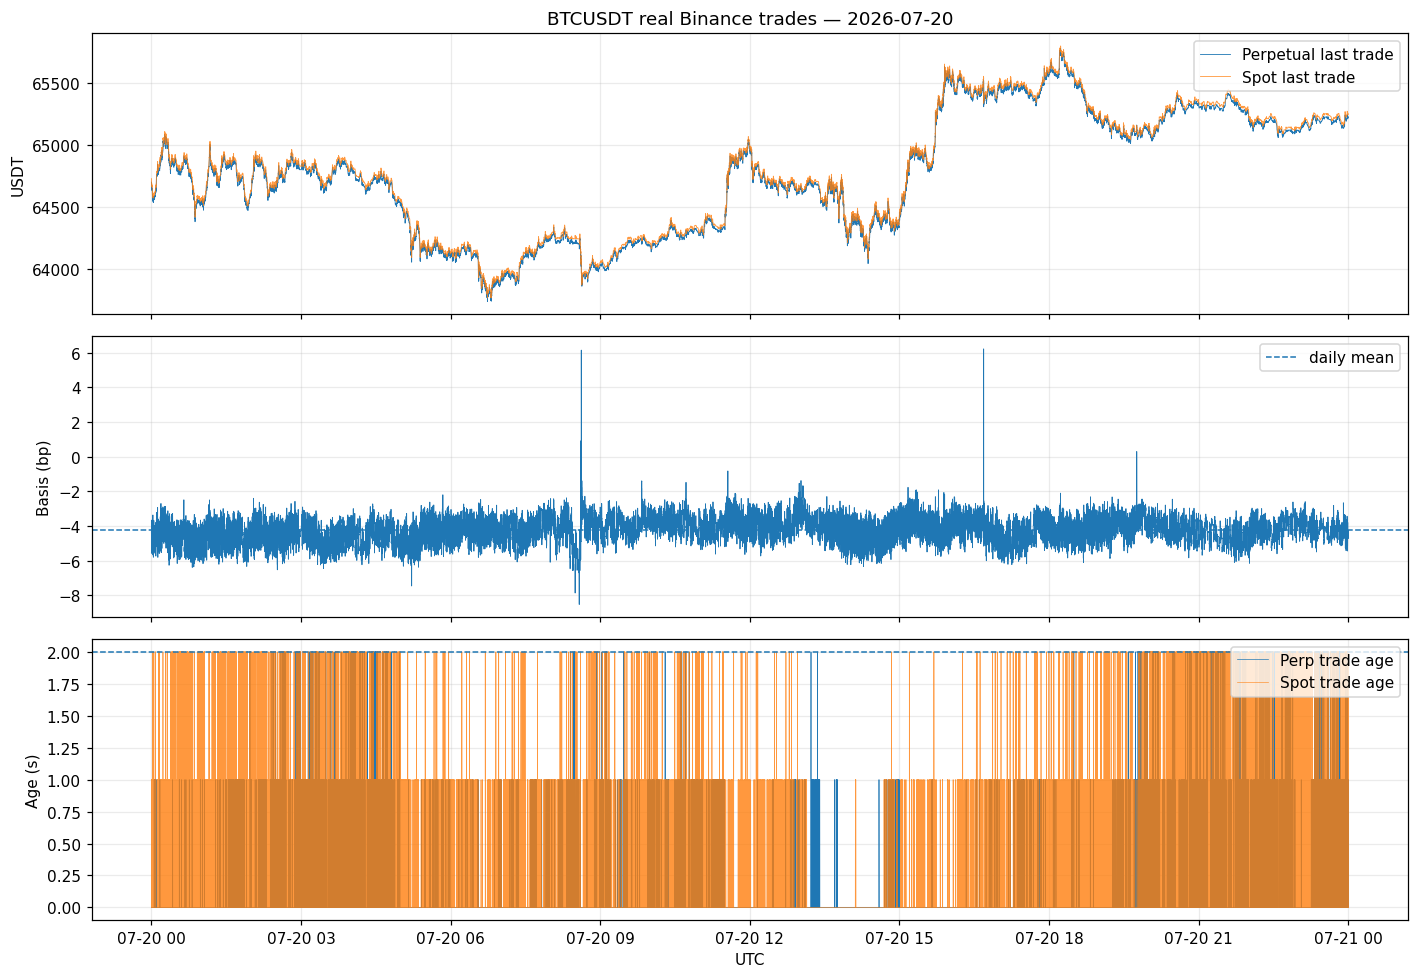

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(aligned.index, aligned["perp_last"], lw=0.55, label="Perpetual last trade")
axes[0].plot(aligned.index, aligned["spot_last"], lw=0.55, alpha=0.8, label="Spot last trade")
axes[0].set_ylabel("USDT")
axes[0].set_title(f"{SYMBOL} real Binance trades — {DATE}")
axes[0].legend(loc="upper right")

axes[1].plot(aligned.index, aligned["basis_bp"], lw=0.55)
axes[1].axhline(aligned["basis_bp"].mean(), ls="--", lw=1, label="daily mean")
axes[1].set_ylabel("Basis (bp)")
axes[1].legend(loc="upper right")

axes[2].plot(aligned.index, aligned["perp_age_s"], lw=0.45, label="Perp trade age")
axes[2].plot(aligned.index, aligned["spot_age_s"], lw=0.45, alpha=0.8, label="Spot trade age")
axes[2].axhline(MAX_STALE_SECONDS, ls="--", lw=1)
axes[2].set_ylabel("Age (s)")
axes[2].set_xlabel("UTC")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. Fit only on the earlier period

The state-space engine is used as follows:

```python
fit = fit_state_space(training_basis)
filtered = filter_state_space(all_basis, fit)
```

`fit_state_space` estimates the structural parameters.  
`filter_state_space` performs the one-sided Kalman recursion and returns the latent level, transient component and innovations.

The fit below sees only the first `TRAIN_OBS` observations. All reported strategy trades occur after that cutoff.

In [6]:
if len(aligned) <= TRAIN_OBS + 1_000:
    raise ValueError(
        f"Only {len(aligned):,} valid observations; reduce TRAIN_OBS={TRAIN_OBS:,}"
    )

y = aligned["basis_log"].to_numpy(dtype=float)
train_y = y[:TRAIN_OBS]

fit = fit_state_space(
    train_y,
    dt=float(BAR_SECONDS),
    max_obs=None,
    burn_in=50,
    compare_null=True,
    require_convergence=True,
)

print(fit.report(scale=1e4, unit="bp"))

State-space basis decomposition
  source observations       : 60,000
  fitted observations       : 60,000
  effective likelihood obs  : 59,950
  converged                 : True
  optimiser message         : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  b (AR1 persistence)       : 0.81347231
  half-life                 : 3.358 s
  sigma_level               : 0.030007 bp/step
  sigma_transient           : 0.296590 bp/step
  sigma_observation         : 0.143047 bp
  stationary transient sd   : 0.509951 bp
  log-likelihood            : 529,989.814
  AIC / BIC                 : -1,059,971.628 / -1,059,935.623
  BIC improvement vs null   : 3,882.525
  near-optimal solutions    : 3
  near-optimal HL ratio     : 1.000
  near-optimal signal ratio : 1.000


In [7]:
filtered = filter_state_space(y, fit)

aligned["level_bp"] = filtered.level * 1e4
aligned["transient_bp"] = filtered.transient * 1e4
aligned["innovation_z"] = filtered.standardized_innovation

# Stable economic z-score: transient relative to its stationary model amplitude.
transient_sd_bp = fit.params.transient_sd * 1e4
aligned["signal_z"] = aligned["transient_bp"] / transient_sd_bp

split_time = aligned.index[TRAIN_OBS]
aligned["sample"] = np.where(
    np.arange(len(aligned)) < TRAIN_OBS,
    "training",
    "out-of-sample",
)

diagnostics = pd.Series(filtered.diagnostics(max_lag=30), name="value").to_frame()
display(diagnostics)
print(f"Out-of-sample begins: {split_time}")

,value
n,8.579500e+04
mean,5.914977e-06
sd,9.328608e-01
ljung_box_q,2.337345e+02
ljung_box_p,2.029316e-33
jarque_bera,2.244140e+06
jarque_bera_p,0.000000e+00


Out-of-sample begins: 2026-07-20 16:43:42+00:00


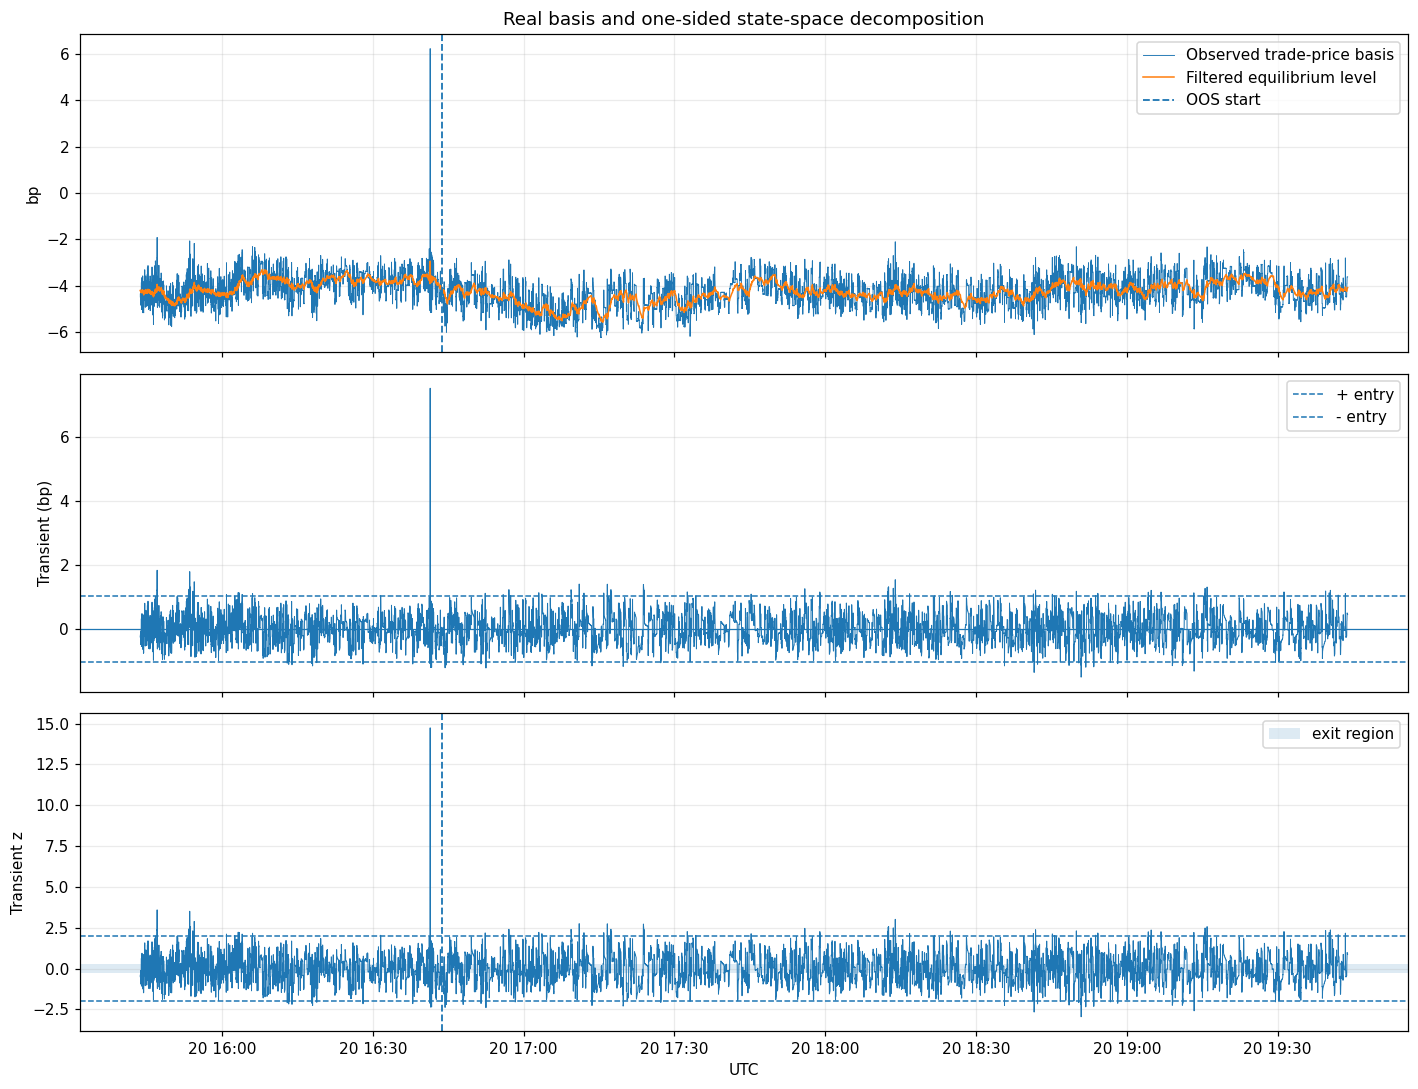

In [8]:
view = aligned.iloc[max(0, TRAIN_OBS - 3_600): min(len(aligned), TRAIN_OBS + 10_800)]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(view.index, view["basis_bp"], lw=0.6, label="Observed trade-price basis")
axes[0].plot(view.index, view["level_bp"], lw=1.0, label="Filtered equilibrium level")
axes[0].axvline(split_time, ls="--", lw=1.2, label="OOS start")
axes[0].set_ylabel("bp")
axes[0].set_title("Real basis and one-sided state-space decomposition")
axes[0].legend(loc="upper right")

axes[1].plot(view.index, view["transient_bp"], lw=0.65)
axes[1].axhline(ENTRY_Z * transient_sd_bp, ls="--", lw=1, label="+ entry")
axes[1].axhline(-ENTRY_Z * transient_sd_bp, ls="--", lw=1, label="- entry")
axes[1].axhline(0, lw=0.8)
axes[1].set_ylabel("Transient (bp)")
axes[1].legend(loc="upper right")

axes[2].plot(view.index, view["signal_z"], lw=0.65)
axes[2].axhline(ENTRY_Z, ls="--", lw=1)
axes[2].axhline(-ENTRY_Z, ls="--", lw=1)
axes[2].axhspan(-EXIT_Z, EXIT_Z, alpha=0.15, label="exit region")
axes[2].axvline(split_time, ls="--", lw=1.2)
axes[2].set_ylabel("Transient z")
axes[2].set_xlabel("UTC")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Out-of-sample diagnostic backtest

Rules:

- A signal observed at second `t` is filled at second `t+1`; no same-bar execution.
- Positive transient: perpetual is rich relative to spot → **long spot / short perp**.
- Negative transient: perpetual is cheap → **long perp / short spot**; disabled unless `ALLOW_SHORT_SPOT=True`.
- Exit near zero, at stop, or at maximum holding time.
- Net P&L deducts four fills: two legs at entry and two at exit.

Because fills use last trades rather than historical bid/ask, the **gross P&L is a signal diagnostic** and net P&L is only a cost-stressed proxy.

In [9]:
ROUND_TRIP_COST_BP = 4.0 * (FEE_BP_PER_FILL + SLIPPAGE_BP_PER_FILL)


def run_proxy_backtest(
    frame: pd.DataFrame,
    *,
    start_pos: int,
    entry_z: float,
    exit_z: float,
    stop_z: float,
    max_hold_seconds: int,
    cooldown_seconds: int,
    allow_short_spot: bool,
    round_trip_cost_bp: float,
) -> pd.DataFrame:
    basis = frame["basis_bp"].to_numpy(dtype=float)
    signal = frame["signal_z"].to_numpy(dtype=float)
    timestamps = frame.index

    trades = []
    position = 0
    pending_action = None
    entry_i = None
    entry_basis = None
    entry_signal = None
    entry_reason = None
    next_allowed_i = start_pos

    # Signal at i-1, proxy fill at i.
    for i in range(max(start_pos + 1, 1), len(frame)):
        decision_i = i - 1

        if pending_action is not None:
            action, reason, originating_signal = pending_action
            pending_action = None

            if action in (-1, 1) and position == 0:
                position = action
                entry_i = i
                entry_basis = basis[i]
                entry_signal = originating_signal
                entry_reason = reason

            elif action == 0 and position != 0:
                gross_bp = position * (basis[i] - entry_basis)
                net_bp = gross_bp - round_trip_cost_bp
                trades.append({
                    "entry_time": timestamps[entry_i],
                    "exit_time": timestamps[i],
                    "side": "long_basis" if position == 1 else "short_basis",
                    "entry_basis_bp": entry_basis,
                    "exit_basis_bp": basis[i],
                    "entry_signal_z": entry_signal,
                    "exit_signal_z": signal[decision_i],
                    "holding_s": (i - entry_i) * BAR_SECONDS,
                    "gross_pnl_bp": gross_bp,
                    "cost_bp": round_trip_cost_bp,
                    "net_pnl_bp": net_bp,
                    "entry_reason": entry_reason,
                    "exit_reason": reason,
                })
                position = 0
                entry_i = entry_basis = entry_signal = entry_reason = None
                next_allowed_i = i + math.ceil(cooldown_seconds / BAR_SECONDS)

        if pending_action is not None:
            continue

        z = signal[decision_i]
        if not np.isfinite(z):
            continue

        if position == 0:
            if decision_i < next_allowed_i:
                continue
            if z >= entry_z:
                # short basis = long spot, short perp; no spot borrow required
                pending_action = (-1, "positive_transient", z)
            elif z <= -entry_z and allow_short_spot:
                pending_action = (1, "negative_transient", z)

        else:
            held_s = (decision_i - entry_i) * BAR_SECONDS
            should_exit = abs(z) <= exit_z
            stopped = (
                (position == -1 and z >= stop_z)
                or (position == 1 and z <= -stop_z)
            )
            timed_out = held_s >= max_hold_seconds

            if stopped:
                pending_action = (0, "stop", z)
            elif should_exit:
                pending_action = (0, "mean_reversion", z)
            elif timed_out:
                pending_action = (0, "max_hold", z)

    return pd.DataFrame(trades)


trades = run_proxy_backtest(
    aligned,
    start_pos=TRAIN_OBS,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    stop_z=STOP_Z,
    max_hold_seconds=MAX_HOLD_SECONDS,
    cooldown_seconds=COOLDOWN_SECONDS,
    allow_short_spot=ALLOW_SHORT_SPOT,
    round_trip_cost_bp=ROUND_TRIP_COST_BP,
)

print(f"Round-trip modelled cost: {ROUND_TRIP_COST_BP:.2f} bp")
print(f"Out-of-sample observations: {len(aligned) - TRAIN_OBS:,}")
print(f"Completed diagnostic trades: {len(trades):,}")
display(trades.head(10))

Round-trip modelled cost: 8.40 bp
Out-of-sample observations: 25,795
Completed diagnostic trades: 68


,entry_time,exit_time,side,entry_basis_bp,exit_basis_bp,entry_signal_z,exit_signal_z,holding_s,gross_pnl_bp,cost_bp,net_pnl_bp,entry_reason,exit_reason
0,2026-07-20 16:52:21+00:00,2026-07-20 16:52:24+00:00,short_basis,-2.949611,-4.050621,2.100490,0.186277,3,1.101010,8.4,-7.298990,positive_transient,mean_reversion
1,2026-07-20 16:55:56+00:00,2026-07-20 16:56:22+00:00,short_basis,-3.293043,-4.514230,2.097940,-0.111912,26,1.221188,8.4,-7.178812,positive_transient,mean_reversion
2,2026-07-20 16:57:05+00:00,2026-07-20 16:57:21+00:00,short_basis,-3.505194,-4.507237,2.402572,-0.193764,16,1.002044,8.4,-7.397956,positive_transient,mean_reversion
3,2026-07-20 17:03:02+00:00,2026-07-20 17:03:04+00:00,short_basis,-5.331753,-4.724152,2.214408,0.647315,2,-0.607601,8.4,-9.007601,positive_transient,mean_reversion
4,2026-07-20 17:03:38+00:00,2026-07-20 17:04:15+00:00,short_basis,-3.941995,-4.866531,2.134410,0.077376,37,0.924537,8.4,-7.475463,positive_transient,mean_reversion
5,2026-07-20 17:09:26+00:00,2026-07-20 17:09:45+00:00,short_basis,-3.709878,-5.020643,2.365138,-0.363504,19,1.310764,8.4,-7.089236,positive_transient,mean_reversion
6,2026-07-20 17:11:03+00:00,2026-07-20 17:11:08+00:00,short_basis,-3.512925,-4.709285,2.632001,0.167384,5,1.196360,8.4,-7.203640,positive_transient,mean_reversion
7,2026-07-20 17:12:01+00:00,2026-07-20 17:12:04+00:00,short_basis,-4.565649,-4.136355,2.191389,-0.168408,3,-0.429294,8.4,-8.829294,positive_transient,mean_reversion
8,2026-07-20 17:15:57+00:00,2026-07-20 17:16:22+00:00,short_basis,-4.189575,-5.673260,2.195933,-0.633881,25,1.483685,8.4,-6.916315,positive_transient,mean_reversion
9,2026-07-20 17:16:39+00:00,2026-07-20 17:17:10+00:00,short_basis,-4.980767,-5.090523,2.514481,-0.284778,31,0.109757,8.4,-8.290243,positive_transient,mean_reversion


,value
trades,68.000000
gross total (bp),43.028460
net total (bp),-528.171540
average gross/trade (bp),0.632771
average net/trade (bp),-7.767229
gross win rate,0.808824
net win rate,0.000000
median holding (s),15.500000
maximum holding (s),62.000000
maximum drawdown (bp),-520.872549


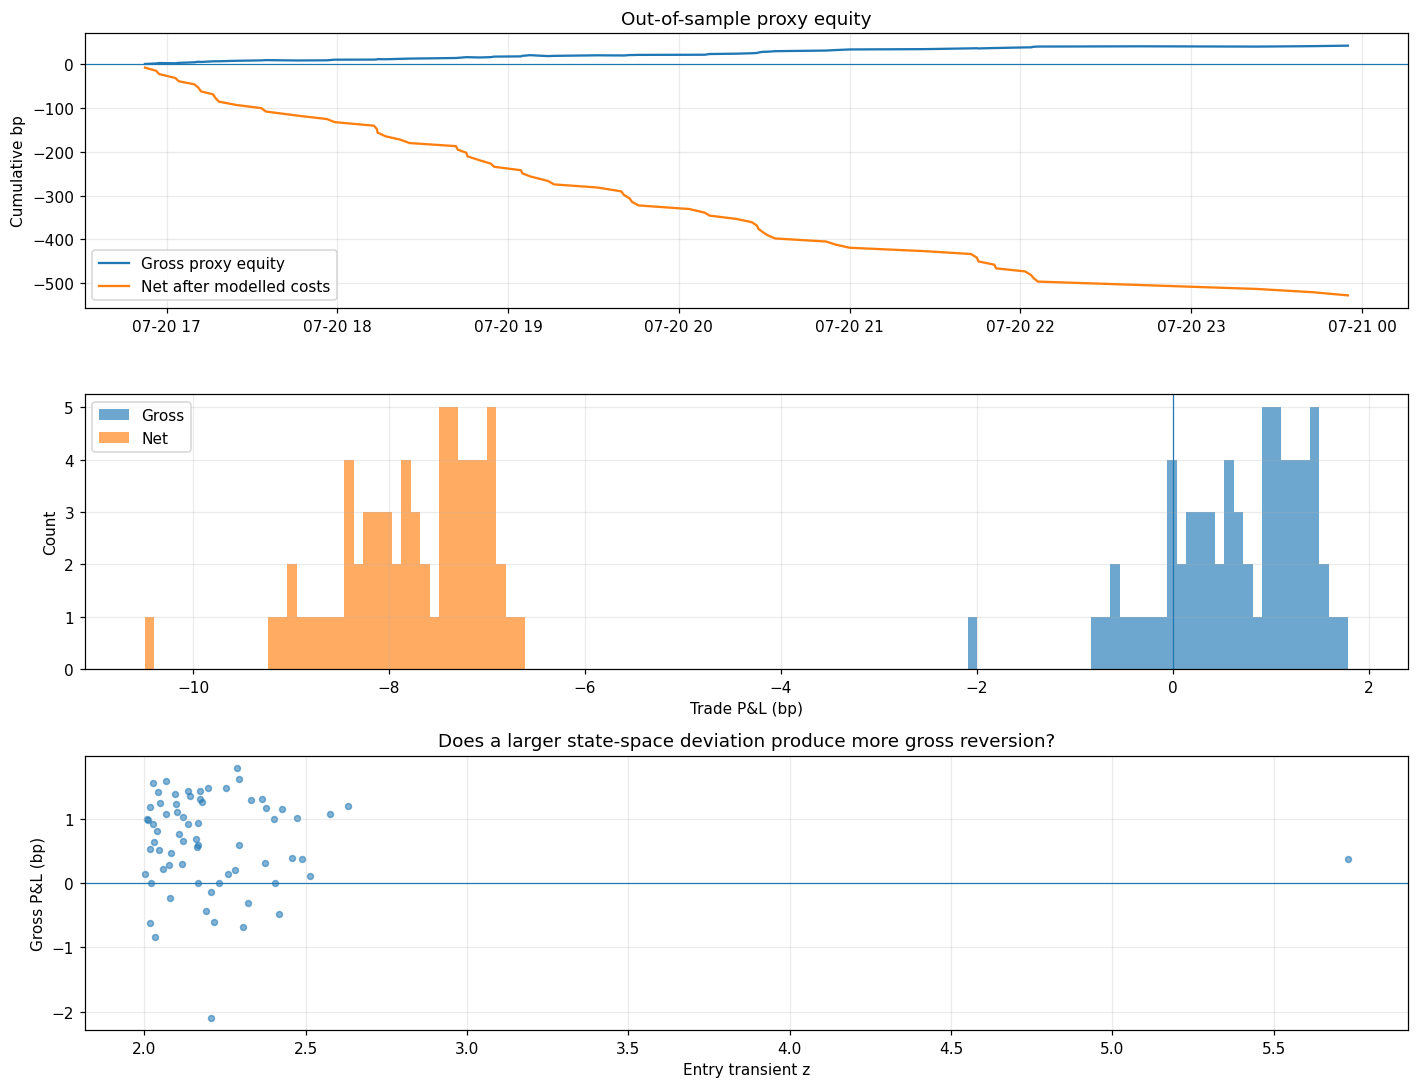

In [10]:
def performance_table(trades: pd.DataFrame) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame({"value": {"trades": 0}})

    gross = trades["gross_pnl_bp"]
    net = trades["net_pnl_bp"]
    equity = net.cumsum()
    drawdown = equity - equity.cummax()

    return pd.DataFrame({
        "value": {
            "trades": len(trades),
            "gross total (bp)": gross.sum(),
            "net total (bp)": net.sum(),
            "average gross/trade (bp)": gross.mean(),
            "average net/trade (bp)": net.mean(),
            "gross win rate": (gross > 0).mean(),
            "net win rate": (net > 0).mean(),
            "median holding (s)": trades["holding_s"].median(),
            "maximum holding (s)": trades["holding_s"].max(),
            "maximum drawdown (bp)": drawdown.min(),
            "cost paid (bp)": trades["cost_bp"].sum(),
        }
    })


perf = performance_table(trades)
display(perf)

if not trades.empty:
    plot_trades = trades.copy()
    plot_trades["gross_equity_bp"] = plot_trades["gross_pnl_bp"].cumsum()
    plot_trades["net_equity_bp"] = plot_trades["net_pnl_bp"].cumsum()

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))

    axes[0].plot(plot_trades["exit_time"], plot_trades["gross_equity_bp"], label="Gross proxy equity")
    axes[0].plot(plot_trades["exit_time"], plot_trades["net_equity_bp"], label="Net after modelled costs")
    axes[0].axhline(0, lw=0.8)
    axes[0].set_ylabel("Cumulative bp")
    axes[0].set_title("Out-of-sample proxy equity")
    axes[0].legend()

    axes[1].hist(plot_trades["gross_pnl_bp"], bins=40, alpha=0.65, label="Gross")
    axes[1].hist(plot_trades["net_pnl_bp"], bins=40, alpha=0.65, label="Net")
    axes[1].axvline(0, lw=0.8)
    axes[1].set_xlabel("Trade P&L (bp)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    axes[2].scatter(
        plot_trades["entry_signal_z"],
        plot_trades["gross_pnl_bp"],
        s=15,
        alpha=0.55,
    )
    axes[2].axhline(0, lw=0.8)
    axes[2].set_xlabel("Entry transient z")
    axes[2].set_ylabel("Gross P&L (bp)")
    axes[2].set_title("Does a larger state-space deviation produce more gross reversion?")

    plt.tight_layout()
    plt.show()

## 5. Threshold sweep on the real out-of-sample period

,entry_z,trades,gross_total_bp,net_total_bp,avg_gross_bp,avg_net_bp
0,0.75,476,196.5562,-3801.8438,0.4129,-7.9871
1,1.00,376,189.9669,-2968.4331,0.5052,-7.8948
2,1.25,280,154.2240,-2197.7760,0.5508,-7.8492
3,1.50,192,104.2143,-1508.5857,0.5428,-7.8572
4,1.75,123,76.7961,-956.4039,0.6244,-7.7756
5,2.00,68,43.0285,-528.1715,0.6328,-7.7672
6,2.25,31,18.9598,-241.4402,0.6116,-7.7884
7,2.50,10,5.4723,-78.5277,0.5472,-7.8528
8,2.75,3,1.0559,-24.1441,0.3520,-8.0480
9,3.00,2,0.1126,-16.6874,0.0563,-8.3437


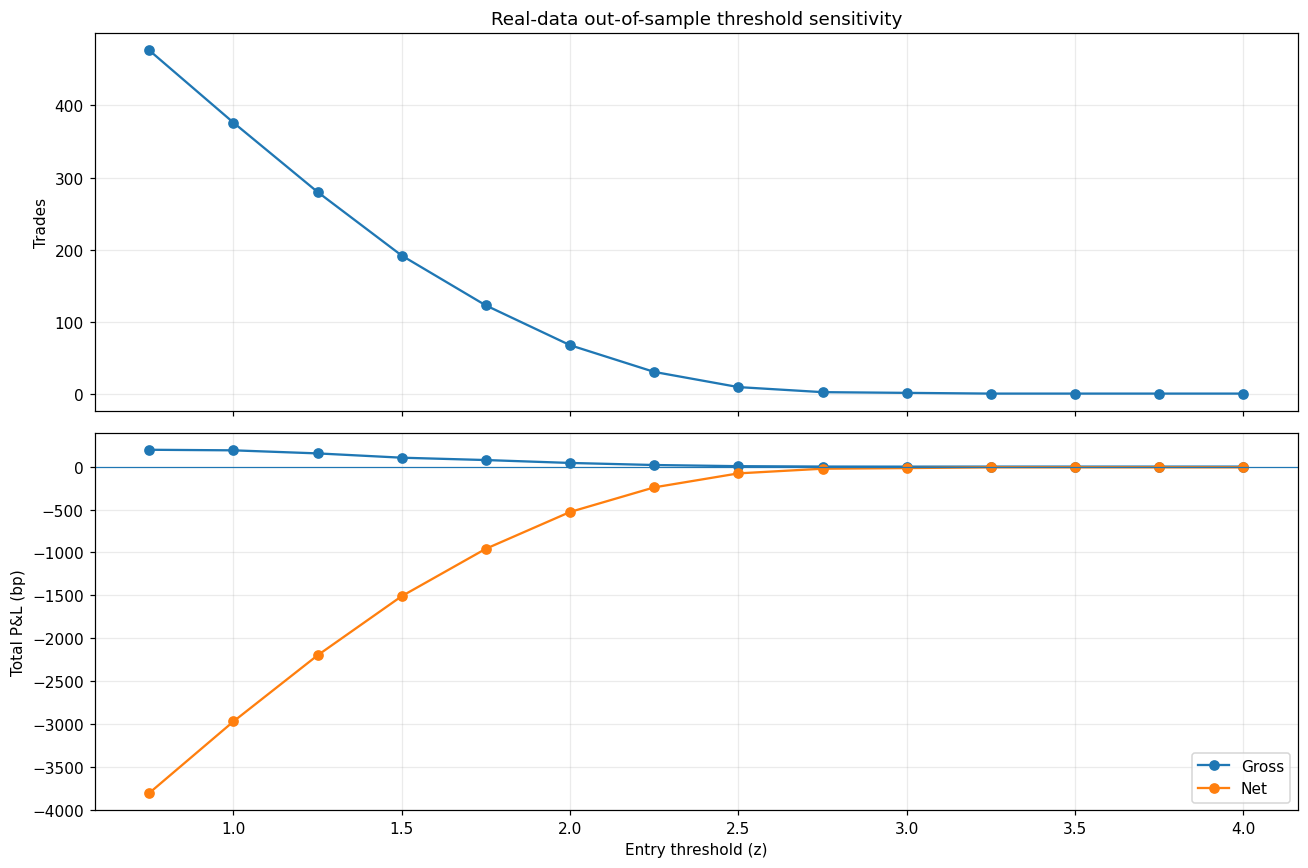

In [11]:
sweep_rows = []
for threshold in np.arange(0.75, 4.01, 0.25):
    candidate = run_proxy_backtest(
        aligned,
        start_pos=TRAIN_OBS,
        entry_z=float(threshold),
        exit_z=EXIT_Z,
        stop_z=max(STOP_Z, float(threshold) + 1.5),
        max_hold_seconds=MAX_HOLD_SECONDS,
        cooldown_seconds=COOLDOWN_SECONDS,
        allow_short_spot=ALLOW_SHORT_SPOT,
        round_trip_cost_bp=ROUND_TRIP_COST_BP,
    )

    if candidate.empty:
        sweep_rows.append({
            "entry_z": threshold,
            "trades": 0,
            "gross_total_bp": 0.0,
            "net_total_bp": 0.0,
            "avg_gross_bp": np.nan,
            "avg_net_bp": np.nan,
        })
    else:
        sweep_rows.append({
            "entry_z": threshold,
            "trades": len(candidate),
            "gross_total_bp": candidate["gross_pnl_bp"].sum(),
            "net_total_bp": candidate["net_pnl_bp"].sum(),
            "avg_gross_bp": candidate["gross_pnl_bp"].mean(),
            "avg_net_bp": candidate["net_pnl_bp"].mean(),
        })

sweep = pd.DataFrame(sweep_rows)
display(sweep.round(4))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(sweep["entry_z"], sweep["trades"], marker="o")
axes[0].set_ylabel("Trades")
axes[0].set_title("Real-data out-of-sample threshold sensitivity")

axes[1].plot(sweep["entry_z"], sweep["gross_total_bp"], marker="o", label="Gross")
axes[1].plot(sweep["entry_z"], sweep["net_total_bp"], marker="o", label="Net")
axes[1].axhline(0, lw=0.8)
axes[1].set_xlabel("Entry threshold (z)")
axes[1].set_ylabel("Total P&L (bp)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Economic decision

In [12]:
cost_to_signal = ROUND_TRIP_COST_BP / transient_sd_bp
bic_improvement = fit.delta_bic_vs_local_level

decision = {
    "real data": True,
    "training observations": TRAIN_OBS,
    "out-of-sample observations": len(aligned) - TRAIN_OBS,
    "half-life (s)": fit.half_life,
    "transient stationary sd (bp)": transient_sd_bp,
    "round-trip modelled cost (bp)": ROUND_TRIP_COST_BP,
    "cost / transient sd": cost_to_signal,
    "BIC improvement vs local-level null": bic_improvement,
    "diagnostic proxy trades": len(trades),
    "gross proxy total (bp)": 0.0 if trades.empty else trades["gross_pnl_bp"].sum(),
    "net proxy total (bp)": 0.0 if trades.empty else trades["net_pnl_bp"].sum(),
}

decision_table = pd.Series(decision, name="value").to_frame()
display(decision_table)

print("\nINTERPRETATION")
if bic_improvement is not None and bic_improvement <= 10:
    print("- The AR(1) transient is not strongly preferred to the local-level null.")
else:
    print("- The state-space transient is statistically preferred to the local-level null.")

if cost_to_signal > 3:
    print("- Modelled round-trip costs are more than 3 transient standard deviations.")
    print("- At this fee setting the strategy fails the economic gate even if mean reversion exists.")
else:
    print("- Costs are within the scale of the transient component; order-book replay is warranted.")

print("- Gross proxy P&L tests signal direction on real trades.")
print("- Net proxy P&L is not executable proof because historical bid/ask and queue position are absent.")

,value
real data,True
training observations,60000
out-of-sample observations,25795
half-life (s),3.357565
transient stationary sd (bp),0.509951
round-trip modelled cost (bp),8.4
cost / transient sd,16.472155
BIC improvement vs local-level null,3882.525382
diagnostic proxy trades,68
gross proxy total (bp),43.02846



INTERPRETATION
- The state-space transient is statistically preferred to the local-level null.
- Modelled round-trip costs are more than 3 transient standard deviations.
- At this fee setting the strategy fails the economic gate even if mean reversion exists.
- Gross proxy P&L tests signal direction on real trades.
- Net proxy P&L is not executable proof because historical bid/ask and queue position are absent.


## 7. How `state_space.py` is used outside the notebook

### Historical fit

```python
from state_space import fit_state_space, filter_state_space

fit = fit_state_space(training_basis_log, dt=1.0)
result = filter_state_space(all_basis_log, fit)

level = result.level
transient = result.transient
signal_z = transient / fit.params.transient_sd
```

### Online update

```python
from state_space import OnlineBasisFilter

online = OnlineBasisFilter.from_history(fit.params, training_basis_log)

for new_basis_log in live_basis_stream:
    state = online.update(new_basis_log)
    print(state["transient"], state["transient_z"])
```

The state-space module estimates and filters the signal. It does not place orders.  
Execution, risk limits, inventory, funding, borrow and reconciliation belong in separate services.